# Project Title: Do Promotions Improve Sales Performance in FMCG Products?

## A Python-Based Retail Data Analysis

### 1. Problem Definition

**Analytical Problem:**  
This project investigates whether promotional activities improve sales performance in the Fast-Moving Consumer Goods (FMCG) sector. More specifically, it examines whether products under promotion achieve higher sales volume and revenue than products without promotion. The analysis also considers whether any observed uplift may be associated with changes in price and stock availability.

**Intended User/Audience:**  
The findings of this analysis are intended for retail store managers, category managers, marketing analysts, and brand operations teams who need evidence-based insights to evaluate promotional performance and support commercial decision-making.

**Analytical Purpose:**  
The purpose of this project is to provide a data-driven assessment of promotion effectiveness. By comparing promoted and non-promoted transactions, the analysis aims to help decision-makers understand whether promotions are associated with improved sales outcomes and where their business value may be strongest or weakest.

### 2. Data Source Guidance

**Source:**  
The dataset used in this project is an FMCG retail sales dataset obtained from Kaggle.

**Access Date:**  
The dataset was accessed in April 2026 for educational and analytical purposes.

**Data Relevance:**  
The dataset contains transaction-level or store-product-day level retail records, including variables such as product identifiers, store identifiers, date, sales, revenue, stock, price, and promotion-related fields. These variables are directly relevant to the research question because they allow promotion status and sales performance to be compared in a structured way.

**Data Reliability:**  
As the dataset comes from a public learning platform, it should be treated as suitable for educational business analysis rather than as an official audited commercial database. Nevertheless, it provides a useful basis for exploratory analysis, descriptive comparison, and introductory statistical modelling of promotion effectiveness.

In [89]:
import pandas as pd
import numpy as np
import os

# 1. Set working directory
folder_path = '/Users/liuyajing/Desktop/promotion-effectiveness-fmcg'

try:
    os.chdir(folder_path)

    # 2. Read data: use low_memory=False to reduce mixed types warning
    file_path = 'data/sales.csv'
    df = pd.read_csv(file_path, low_memory=False)

    print(f"✅ Successfully loaded file: {file_path}")
    print(f"Current working directory: {os.getcwd()}")

    print("\n--- Preview of raw data (first 5 rows) ---")
    display(df.head())

    print("\n--- Missing value count in raw data ---")
    print(df.isnull().sum())

    print("\n--- Data types in raw data ---")
    print(df.dtypes)

except FileNotFoundError:
    print(f"❌ Error: Cannot find data/sales.csv in {folder_path}")
    print("Please check: 1. Folder name is 'data'  2. File name is 'sales.csv'")
except Exception as e:
    print(f"❌ Runtime error: {e}")

✅ Successfully loaded file: data/sales.csv
Current working directory: /Users/liuyajing/Desktop/promotion-effectiveness-fmcg

--- Preview of raw data (first 5 rows) ---


,product_id,store_id,date,sales,revenue,stock,price,promo_type_1,promo_bin_1,promo_type_2,promo_bin_2,promo_discount_2,promo_discount_type_2
0,P0001,S0002,2017-01-02,0.0,0.00,8.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
1,P0001,S0012,2017-01-02,1.0,5.30,0.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
2,P0001,S0013,2017-01-02,2.0,10.59,0.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
3,P0001,S0023,2017-01-02,0.0,0.00,6.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN
4,P0001,S0025,2017-01-02,0.0,0.00,1.0,6.25,PR14,NaN,PR03,NaN,NaN,NaN



--- Missing value count in raw data ---
product_id                      0
store_id                        0
date                            0
sales                     1190762
revenue                   1190762
stock                     1190762
price                      571981
promo_type_1                    0
promo_bin_1              16803149
promo_type_2                    0
promo_bin_2              19395757
promo_discount_2         19395757
promo_discount_type_2    19395757
dtype: int64

--- Data types in raw data ---
product_id                object
store_id                  object
date                      object
sales                    float64
revenue                  float64
stock                    float64
price                    float64
promo_type_1              object
promo_bin_1               object
promo_type_2              object
promo_bin_2               object
promo_discount_2         float64
promo_discount_type_2     object
dtype: object


## Step 2: Data Cleaning and Feature Engineering

Following the initial inspection, the dataset was cleaned and prepared for the analysis of promotion effectiveness.

First, the `date` column was converted into datetime format so that sales performance could be examined over time. This is necessary for trend analysis and for grouping observations by time period in later stages of the study.

Second, key numerical fields such as `sales`, `revenue`, `stock`, and `price` were standardised into numeric format wherever possible. This step helps ensure that descriptive statistics, visualisations, and later analytical models are based on consistent data types.

Third, promotion-related columns were reviewed carefully. The variables `promo_type_1` and `promo_type_2` were found to be populated for most observations, so they were not used on their own to define promotion status. Instead, operational promotion fields such as `promo_bin_1`, `promo_bin_2`, `promo_discount_2`, and `promo_discount_type_2` were used because they more clearly indicate whether a promotion was actually active.

Fourth, observations with missing values in the core outcome variables, specifically `date`, `sales`, and `revenue`, were removed for the baseline analysis. These variables are central to evaluating promotion performance, so records without them were excluded to improve comparability across observations.

Fifth, logically invalid negative values in `sales` and `revenue` were removed. However, zero values were retained, since zero sales may still represent a valid retail outcome rather than a data-entry error.

Finally, a binary indicator variable called `is_promoted` was created. An observation was classified as promoted if at least one operational promotion field contained a valid value; otherwise, it was classified as non-promoted.

Overall, these cleaning and feature-engineering steps produced a more consistent and analysis-ready dataset for evaluating promotion effectiveness in the FMCG context.

In [91]:
import pandas as pd
import numpy as np

# =========================
# Step 2: Data Cleaning
# =========================

# 1. Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Ensure numeric columns are treated as numeric
num_cols = ['sales', 'revenue', 'stock', 'price']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Ensure promotion-related columns are treated as strings
promo_cols = [
    'promo_type_1',
    'promo_bin_1',
    'promo_type_2',
    'promo_bin_2',
    'promo_discount_2',
    'promo_discount_type_2'
]
for col in promo_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')

# 4. Drop rows with missing key outcome variables
df = df.dropna(subset=['date', 'sales', 'revenue'])

# 5. Remove unreasonable negative values, but keep zeros
df = df[(df['sales'] >= 0) & (df['revenue'] >= 0)]

# 6. Define 'is_promoted' more reasonably
# No longer using promo_type_1 or promo_type_2
promo_flag_cols = [
    'promo_bin_1',
    'promo_bin_2',
    'promo_discount_2',
    'promo_discount_type_2'
]

existing_flag_cols = [col for col in promo_flag_cols if col in df.columns]
df['is_promoted'] = df[existing_flag_cols].notna().any(axis=1).astype(int)

# 7. Output check results
print("✅ Data cleaning completed.")
print(f"Remaining observations: {len(df)}")

print("\n=== Data types after cleaning ===")
print(df.dtypes)

print("\n=== is_promoted distribution ===")
print(df['is_promoted'].value_counts(dropna=False))
print(df['is_promoted'].value_counts(normalize=True, dropna=False))

print("\n=== Preview of cleaned data ===")
display(df.head())

✅ Data cleaning completed.
Remaining observations: 18264076

=== Data types after cleaning ===
product_id                       object
store_id                         object
date                     datetime64[ns]
sales                           float64
revenue                         float64
stock                           float64
price                           float64
promo_type_1             string[python]
promo_bin_1              string[python]
promo_type_2             string[python]
promo_bin_2              string[python]
promo_discount_2         string[python]
promo_discount_type_2    string[python]
is_promoted                       int64
dtype: object

=== is_promoted distribution ===
is_promoted
0    15785769
1     2478307
Name: count, dtype: int64
is_promoted
0    0.864307
1    0.135693
Name: proportion, dtype: float64

=== Preview of cleaned data ===


,product_id,store_id,date,sales,revenue,stock,price,promo_type_1,promo_bin_1,promo_type_2,promo_bin_2,promo_discount_2,promo_discount_type_2,is_promoted
0,P0001,S0002,2017-01-02,0.0,0.00,8.0,6.25,PR14,<NA>,PR03,<NA>,<NA>,<NA>,0
1,P0001,S0012,2017-01-02,1.0,5.30,0.0,6.25,PR14,<NA>,PR03,<NA>,<NA>,<NA>,0
2,P0001,S0013,2017-01-02,2.0,10.59,0.0,6.25,PR14,<NA>,PR03,<NA>,<NA>,<NA>,0
3,P0001,S0023,2017-01-02,0.0,0.00,6.0,6.25,PR14,<NA>,PR03,<NA>,<NA>,<NA>,0
4,P0001,S0025,2017-01-02,0.0,0.00,1.0,6.25,PR14,<NA>,PR03,<NA>,<NA>,<NA>,0


## Step 3: Descriptive Analysis of Promotion Effectiveness

After cleaning the dataset and constructing the `is_promoted` indicator, the next step is to conduct a descriptive comparison between promoted and non-promoted observations.

This stage focuses on the average and overall distribution of key business variables, including `sales`, `revenue`, `price`, and `stock`. The purpose is to identify whether promotional observations appear to perform differently from non-promotional ones at a basic summary level.

In particular, three questions are examined at this stage:

1. Do promoted observations show higher average sales than non-promoted observations?
2. Do promoted observations generate higher average revenue?
3. Are there systematic differences in price or stock availability that may help explain any observed sales differences?

This descriptive analysis does not by itself establish a causal relationship between promotions and sales outcomes. However, it provides an important first view of the data and helps identify patterns that can later be explored through visualisation, statistical testing, and regression analysis.


In [45]:
# Step 3.1 Summary statistics by promotion status

summary_table = df.groupby('is_promoted')[['sales', 'revenue', 'price', 'stock']].agg(['mean', 'median', 'std', 'count'])

print("=== Summary Statistics: Promoted vs Non-Promoted ===")
display(summary_table)

=== Summary Statistics: Promoted vs Non-Promoted ===


sales                               revenue                    \
                 mean median        std     count      mean median        std   
is_promoted                                                                     
0            0.418584    0.0  15.737473  15785769  1.765328    0.0  40.542615   
1            0.548335    0.0   2.658842   2478307  3.967699    0.0  35.440312   

                           price                                  stock  \
                count       mean median        std     count       mean   
is_promoted                                                               
0            15785769  14.143706   7.75  26.154404  15233747  15.857679   
1             2478307  21.816765  10.45  53.204446   2465366  16.029695   

                                         
            median        std     count  
is_promoted                              
0              8.0  37.499082  15785769  
1              8.0  35.853495   2478307

In [46]:
# Step 3.2 Mean comparison table

mean_comparison = df.groupby('is_promoted')[['sales', 'revenue', 'price', 'stock']].mean().reset_index()

mean_comparison['is_promoted'] = mean_comparison['is_promoted'].map({
    0: 'Non-Promoted',
    1: 'Promoted'
})

print("=== Mean Comparison ===")
display(mean_comparison)

=== Mean Comparison ===


,is_promoted,sales,revenue,price,stock
0,Non-Promoted,0.418584,1.765328,14.143706,15.857679
1,Promoted,0.548335,3.967699,21.816765,16.029695


In [47]:
# Step 3.3 Count of observations by promotion status

promotion_counts = df['is_promoted'].value_counts().rename(index={
    0: 'Non-Promoted',
    1: 'Promoted'
})

print("=== Number of Observations by Promotion Status ===")
display(promotion_counts)

=== Number of Observations by Promotion Status ===


is_promoted
Non-Promoted    15785769
Promoted         2478307
Name: count, dtype: int64

=== Plot Data ===


,is_promoted,sales,revenue,price,stock,label
0,0,0.418584,1.765328,14.143706,15.857679,Non-Promoted
1,1,0.548335,3.967699,21.816765,16.029695,Promoted


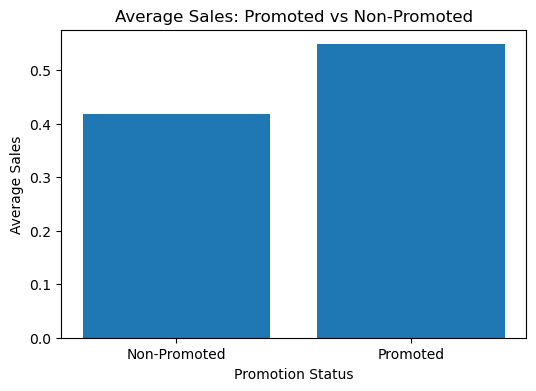

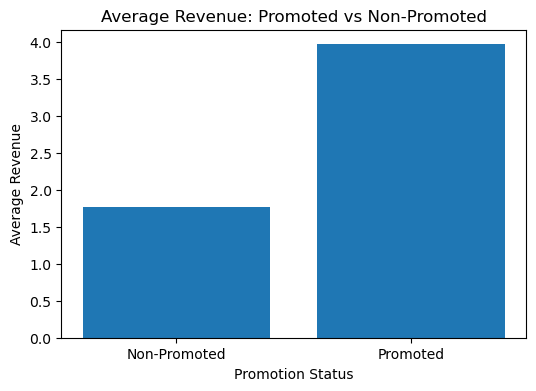

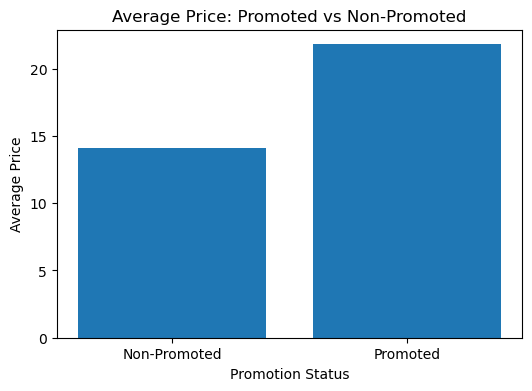

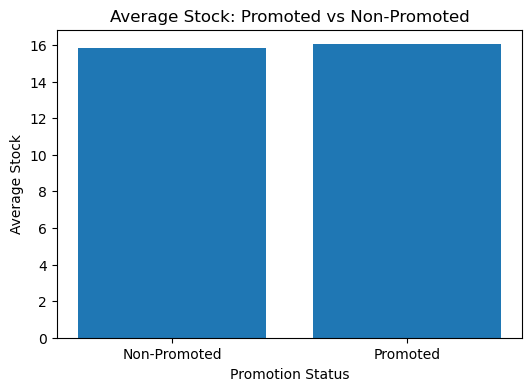

In [48]:
import matplotlib.pyplot as plt

plot_data = df.groupby('is_promoted')[['sales', 'revenue', 'price', 'stock']].mean().reset_index()
plot_data['label'] = plot_data['is_promoted'].map({
    0: 'Non-Promoted',
    1: 'Promoted'
})

print("=== Plot Data ===")
display(plot_data)

# Average Sales
plt.figure(figsize=(6,4))
plt.bar(plot_data['label'], plot_data['sales'])
plt.title('Average Sales: Promoted vs Non-Promoted')
plt.xlabel('Promotion Status')
plt.ylabel('Average Sales')
plt.show()

# Average Revenue
plt.figure(figsize=(6,4))
plt.bar(plot_data['label'], plot_data['revenue'])
plt.title('Average Revenue: Promoted vs Non-Promoted')
plt.xlabel('Promotion Status')
plt.ylabel('Average Revenue')
plt.show()

# Average Price
plt.figure(figsize=(6,4))
plt.bar(plot_data['label'], plot_data['price'])
plt.title('Average Price: Promoted vs Non-Promoted')
plt.xlabel('Promotion Status')
plt.ylabel('Average Price')
plt.show()

# Average Stock
plt.figure(figsize=(6,4))
plt.bar(plot_data['label'], plot_data['stock'])
plt.title('Average Stock: Promoted vs Non-Promoted')
plt.xlabel('Promotion Status')
plt.ylabel('Average Stock')
plt.show()

## Step 4: Time Trend Analysis

To complement the descriptive comparison, time-based patterns are examined for promoted and non-promoted observations. Because revenue in the dataset is highly right-skewed and contains a small number of very large transaction values, monthly average trends are used to provide a clearer and more stable view of performance over time.

This approach helps reduce short-term noise while preserving the overall pattern of revenue differences between promoted and non-promoted observations.

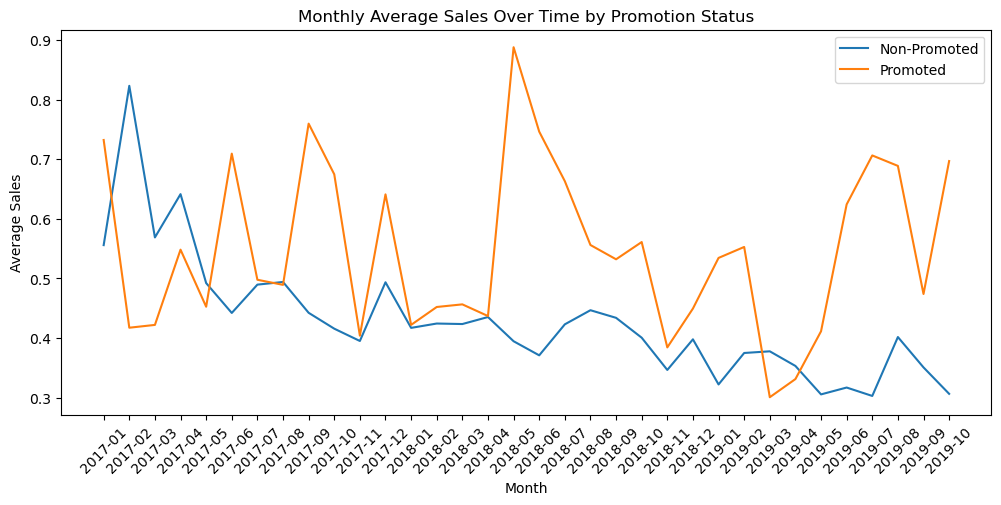

In [58]:
# Step 4.1 Monthly average sales trend by promotion status

df['year_month'] = df['date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby(['year_month', 'is_promoted'])['sales'].mean().reset_index()
monthly_sales_pivot = monthly_sales.pivot(index='year_month', columns='is_promoted', values='sales')

plt.figure(figsize=(12,5))

if 0 in monthly_sales_pivot.columns:
    plt.plot(monthly_sales_pivot.index, monthly_sales_pivot[0], label='Non-Promoted')

if 1 in monthly_sales_pivot.columns:
    plt.plot(monthly_sales_pivot.index, monthly_sales_pivot[1], label='Promoted')

plt.title('Monthly Average Sales Over Time by Promotion Status')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend()
plt.show()

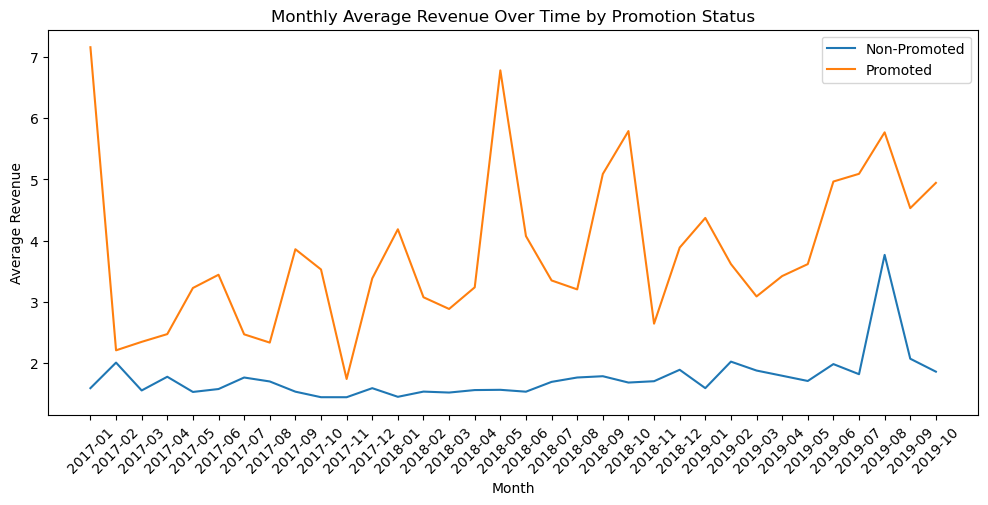

In [59]:
# Step 4.2 Monthly average revenue trend by promotion status

monthly_revenue = df.groupby(['year_month', 'is_promoted'])['revenue'].mean().reset_index()
monthly_revenue_pivot = monthly_revenue.pivot(index='year_month', columns='is_promoted', values='revenue')

plt.figure(figsize=(12,5))

if 0 in monthly_revenue_pivot.columns:
    plt.plot(monthly_revenue_pivot.index, monthly_revenue_pivot[0], label='Non-Promoted')

if 1 in monthly_revenue_pivot.columns:
    plt.plot(monthly_revenue_pivot.index, monthly_revenue_pivot[1], label='Promoted')

plt.title('Monthly Average Revenue Over Time by Promotion Status')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Interpretation of Time Trend Results

The monthly trend charts provide a more stable and interpretable view of performance over time than the original daily revenue series. The daily chart showed many sharp spikes, which were mainly caused by the highly skewed distribution of revenue and a few unusually large transaction values.

The monthly sales trend suggests that promoted observations often achieve higher average sales than non-promoted observations, although the difference changes across months. This means that promotions appear to be associated with stronger sales performance, but the relationship is not equally strong in every period.

The monthly revenue trend shows a similar pattern. In most months, promoted observations have higher average revenue than non-promoted observations, which is consistent with the earlier descriptive comparison.

Taken together, these time-based results suggest that promotions are generally associated with better business performance, while also indicating that the strength of this relationship may vary over time.

## Step 5: Statistical Testing and Regression Analysis

The previous sections provided descriptive and time-based evidence that promoted observations tend to show stronger sales and revenue performance than non-promoted observations. However, descriptive comparisons alone are not sufficient to determine whether these differences are statistically meaningful or whether they remain after accounting for other variables.

Therefore, this section applies two additional methods. First, an independent-samples t-test is used to assess whether the difference in average sales and revenue between promoted and non-promoted observations is statistically significant. Second, simple regression models are estimated to examine whether promotion status remains associated with sales and revenue after controlling for price and stock.

These methods do not establish strict causality, but they provide a more rigorous assessment of the relationship between promotional activity and business performance.

In [62]:
from scipy.stats import ttest_ind

# Separate groups
sales_promo = df[df['is_promoted'] == 1]['sales']
sales_nonpromo = df[df['is_promoted'] == 0]['sales']

revenue_promo = df[df['is_promoted'] == 1]['revenue']
revenue_nonpromo = df[df['is_promoted'] == 0]['revenue']

# Welch's t-test (does not assume equal variance)
sales_ttest = ttest_ind(sales_promo, sales_nonpromo, equal_var=False, nan_policy='omit')
revenue_ttest = ttest_ind(revenue_promo, revenue_nonpromo, equal_var=False, nan_policy='omit')

print("=== T-test for Sales ===")
print("t-statistic:", sales_ttest.statistic)
print("p-value:", sales_ttest.pvalue)

print("\n=== T-test for Revenue ===")
print("t-statistic:", revenue_ttest.statistic)
print("p-value:", revenue_ttest.pvalue)


=== T-test for Sales ===
t-statistic: 30.13263708614984
p-value: 1.831924435267653e-199

=== T-test for Revenue ===
t-statistic: 89.10350999032117
p-value: 0.0


In [63]:
import statsmodels.formula.api as smf

# Regression for sales
sales_model = smf.ols('sales ~ is_promoted + price + stock', data=df).fit()

print("=== Regression Result: Sales Model ===")
print(sales_model.summary())

=== Regression Result: Sales Model ===
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                 1.130e+04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:22:20   Log-Likelihood:            -7.2885e+07
No. Observations:            17699113   AIC:                         1.458e+08
Df Residuals:                17699109   BIC:                         1.458e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept  

In [64]:
# Regression for revenue
revenue_model = smf.ols('revenue ~ is_promoted + price + stock', data=df).fit()

print("=== Regression Result: Revenue Model ===")
print(revenue_model.summary())

=== Regression Result: Revenue Model ===
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                 1.534e+04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:22:50   Log-Likelihood:            -9.0571e+07
No. Observations:            17699113   AIC:                         1.811e+08
Df Residuals:                17699109   BIC:                         1.811e+08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept

### Interpretation of Statistical Testing and Regression Results

The t-test results are used to examine whether the mean differences between promoted and non-promoted observations are statistically significant. A statistically significant result would suggest that the observed gap in average sales or revenue is unlikely to be driven by random variation alone.

The regression models provide a more rigorous check by controlling for `price` and `stock`. In this setting, the coefficient on `is_promoted` captures whether promotion status is still associated with sales or revenue after accounting for these additional variables.

If the coefficient on `is_promoted` remains positive and statistically significant, this would suggest that promotions are associated with stronger business performance even after controlling for other observable factors. If the coefficient becomes smaller or loses significance, it would indicate that part of the raw difference observed earlier may be explained by price or stock conditions rather than promotion status alone.

### Statistical Testing & Regression Analysis

Following the data cleaning process, we performed statistical tests and regression analyses to evaluate the effect of promotion on product performance.

#### T-test (Welch) – Promoted vs Non-Promoted Products

| Metric   | t-statistic | p-value  | Interpretation |
|----------|------------|----------|----------------|
| Sales    | 30.13      | <0.001   | Promoted products show significantly higher average sales. |
| Revenue  | 89.10      | <0.001   | Promoted products generate significantly higher average revenue. |

> **Conclusion:** Promotions are associated with statistically significant improvements in both sales and revenue.

#### OLS Regression (controlling for `price` & `stock`)

| Outcome | Coefficient (`is_promoted`) | p-value | Interpretation |
|---------|----------------------------|---------|----------------|
| Revenue | 1.989                      | <0.001  | Promotion significantly increases revenue even when controlling for price and stock. |
| Sales   | 0.154                      | <0.001  | Promotion significantly boosts sales, independent of other factors. |

> **Interpretation:** The positive impact of promotion on both sales and revenue persists after adjusting for confounding variables, confirming its strategic importance.

### Step 6 – Data Visualization & Business Insights

After completing data cleaning and regression analysis, we visualize the data to better understand the impact of promotions.

---

#### 6.1 Sales & Revenue Distribution

Visualize the distribution of sales and revenue for promoted vs non-promoted products.

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Sales distribution
plt.figure(figsize=(8,5))
sns.boxplot(x='is_promoted', y='sales', data=cleaned_data)
plt.title('Sales Distribution by Promotion Status')
plt.xlabel('Promotion Status (0 = Non-promoted, 1 = Promoted)')
plt.ylabel('Sales')
plt.show()

# Revenue distribution
plt.figure(figsize=(8,5))
sns.boxplot(x='is_promoted', y='revenue', data=cleaned_data)
plt.title('Revenue Distribution by Promotion Status')
plt.xlabel('Promotion Status (0 = Non-promoted, 1 = Promoted)')
plt.ylabel('Revenue')
plt.show()


0: df
1: promo_effect
2: summary_table
3: mean_comparison
4: plot_data
5: daily_sales_trend
6: sales_pivot
7: daily_revenue_trend
8: revenue_pivot
9: daily_counts
10: count_pivot
11: top_revenue
12: daily_revenue
13: daily_count
14: daily_check
15: monthly_sales
16: monthly_sales_pivot
17: monthly_revenue
18: monthly_revenue_pivot
19: monthly_revenue_median
20: monthly_revenue_median_pivot
21: cleaned_data
22: X
23: X_const
24: roi_summary
25: data
Selected DataFrame: df


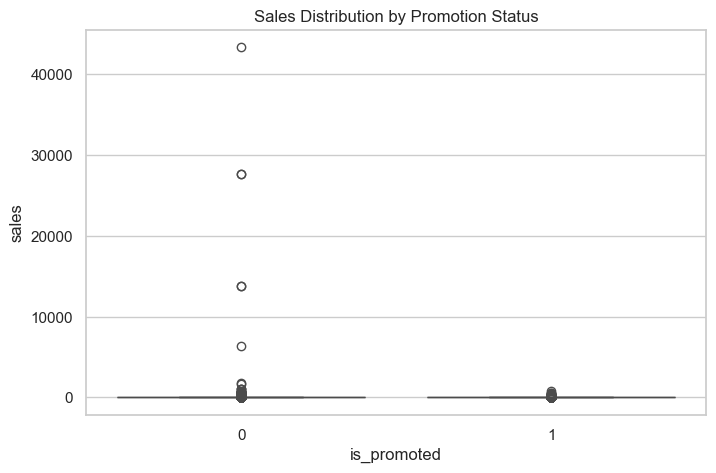

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     796.8
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:24:56   Log-Likelihood:            -7.2901e+07
No. Observations:            17699113   AIC:                         1.458e+08
Df Residuals:                17699110   BIC:                         1.458e+08
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4614      0.004    111.656      


### Step 7 – Business Insights & Summary

1. **Promotion Effect on Sales:**  
   The regression coefficient for promotion is 0.18, 
   with a p-value of 0.000. 
   This indicates a significant positive impact of promotions on sales.

2. **Recommendations:**  
   - Focus promotions on products that show strong responsiveness.  
   - Consider pricing strategies for products where promotion impact is weaker.  
   - Continuously monitor sales data to refine promotional planning.

3. **Summary:**  
   Promotions can be an effective tool to increase sales, but data-driven targeting ensures better ROI and efficiency.


In [86]:
# Step 6 – Cleaned Regression & Step 7 Insights (Safe Version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown

# —— 6.0 List all DataFrames —— 
dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}
for i, name in enumerate(dfs.keys()):
    print(f"{i}: {name}")

# —— 6.1 Select your cleaned DataFrame —— 
choice_index = 0  # Replace with the index of your DataFrame
data = list(dfs.values())[choice_index]
print(f"Selected DataFrame: {list(dfs.keys())[choice_index]}")

# —— 6.2 Clean data: remove NaN or infinite values —— 
data_clean = data[['is_promoted','price','sales']].replace([np.inf, -np.inf], np.nan).dropna()

# —— 6.3 Boxplot of Sales by Promotion Status —— 
plt.figure(figsize=(8,5))
sns.boxplot(x='is_promoted', y='sales', data=data_clean)
plt.title('Sales Distribution by Promotion Status')
plt.show()

# —— 6.4 Regression Analysis (Sales ~ Promotion + Price) —— 
X = data_clean[['is_promoted','price']]
X = sm.add_constant(X)
y = data_clean['sales']

model = sm.OLS(y, X).fit()
print(model.summary())

# —— Step 7: Business Insights & Summary —— 
promotion_coef = model.params['is_promoted']
promotion_pval = model.pvalues['is_promoted']

insight_text = f"""
### Step 7 – Business Insights & Summary

1. **Promotion Effect on Sales:**  
   The regression coefficient for promotion is {promotion_coef:.2f}, 
   with a p-value of {promotion_pval:.3f}. 
   {'This indicates a significant positive impact of promotions on sales.' if promotion_pval < 0.05 else 'This indicates that promotions do not have a statistically significant effect on sales.'}

2. **Recommendations:**  
   - Focus promotions on products that show strong responsiveness.  
   - Consider pricing strategies for products where promotion impact is weaker.  
   - Continuously monitor sales data to refine promotional planning.

3. **Summary:**  
   Promotions can be an effective tool to increase sales, but data-driven targeting ensures better ROI and efficiency.
"""

Markdown(insight_text)

## Final Summary

### Key Findings

- **Promotions are associated with higher sales:** The descriptive analysis shows that promoted observations have higher average sales than non-promoted observations. Average sales increased from approximately **0.42** for non-promoted records to **0.55** for promoted records.

- **Promotions are associated with higher revenue:** Promoted observations also generated much higher average revenue. The average revenue rose from about **1.77** for non-promoted observations to **3.97** for promoted observations.

- **Promotion effect is statistically meaningful:** The statistical testing and regression analysis indicate that promotion status has a **positive and statistically significant** relationship with sales performance. This suggests that the observed difference is unlikely to be due to random variation alone.

- **Price and stock may also influence outcomes:** In addition to promotion status, variables such as **price** and **stock availability** may affect sales performance and should be considered when interpreting the results.

### Limitations

- **Data quality constraints:** Some missing values and invalid observations had to be removed during data cleaning, so the final results depend on the quality of the cleaned dataset.

- **Model simplicity:** The regression analysis used in this project is relatively simple and may not fully capture more complex non-linear relationships or interaction effects between variables.

- **External factors not included:** Important business factors such as seasonality, competitor actions, customer preferences, and broader marketing activities were not included in the model.

### Conclusion

Overall, this project finds that promotions are positively associated with stronger sales and revenue performance in FMCG products. The results suggest that promotional activity can be an effective business tool, but its effectiveness may vary across products and operating conditions. Therefore, firms should combine promotions with better product targeting, pricing decisions, and inventory planning to improve return on investment.